In [16]:
import time
from datetime import datetime

notebook_start = time.time()
print(f"Notebook tracking started at: {datetime.now().strftime('%H:%M:%S')}")


Notebook tracking started at: 16:41:51


In [17]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("../DataBox/Churn_Modelling.csv")
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

# Encode String Columns
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [19]:
df.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [20]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [21]:

scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [22]:
model = Sequential()

# Input layer + Hidden Layer 1: Switched to relu for faster learning
model.add(Dense(11, activation='relu', input_dim=11))

# Hidden Layer 2: Switched to relu
model.add(Dense(11, activation='relu'))

# Output Layer: Keep sigmoid to output a probability between 0 and 1
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


C:\Users\parij\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [25]:
history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6927 - loss: 2285.2866 - val_accuracy: 0.6744 - val_loss: 352.3691
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 167.6139 - val_accuracy: 0.6187 - val_loss: 137.0879
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6933 - loss: 124.9837 - val_accuracy: 0.7225 - val_loss: 101.3326
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 86.2503 - val_accuracy: 0.6450 - val_loss: 95.2430
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6942 - loss: 67.3479 - val_accuracy: 0.5525 - val_loss: 77.6101
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6836 - loss: 47.3180 - val_accuracy: 0.5150 - val_loss: 82.8746
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6917 - loss: 39.4432 - val_accuracy: 0.7969 - val_loss: 61.8229
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6933 - lo

In [26]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=-1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [27]:
accuracy_score(y_test,y_pred)

0.7975

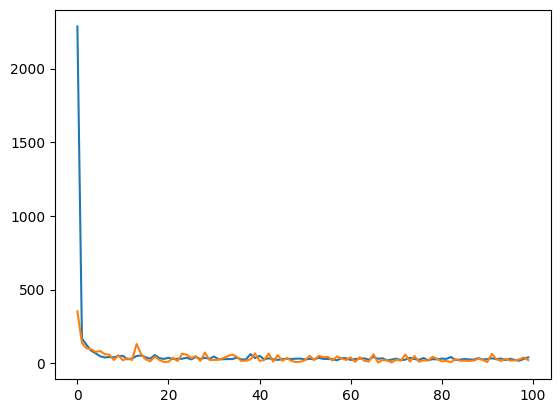

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

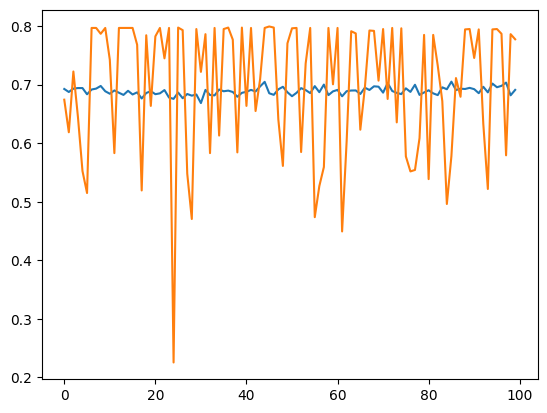

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [30]:
import time
from datetime import datetime

notebook_end = time.time()
total_seconds = notebook_end - notebook_start

# Format seconds into hours, minutes, and seconds
hours, rem = divmod(total_seconds, 3600)
minutes, seconds = divmod(rem, 60)

print(f"Finished at: {datetime.now().strftime('%H:%M:%S')}")
print(f"Total Notebook Runtime: {int(hours)}h {int(minutes)}m {seconds:.2f}s")


Finished at: 16:42:24
Total Notebook Runtime: 0h 0m 32.53s
